<a href="https://colab.research.google.com/github/hananlu/aiBigData/blob/master/Week_4_ModelEvaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Evaluation Model Regression

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Load dataset
data = load_diabetes()

X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = LinearRegression()

model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 42.79409467959994
MSE: 2900.193628493482
RMSE: 53.85344583676593
R2: 0.4526027629719195


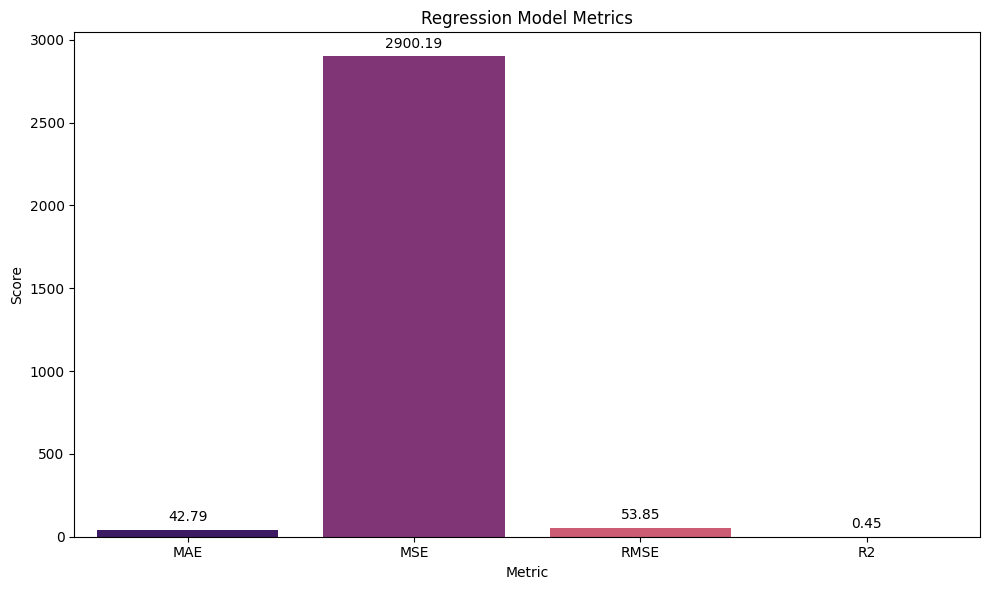

In [31]:
regression_metrics_data = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae, mse, rmse, r2]
}
regression_metrics_df = pd.DataFrame(regression_metrics_data)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Value', hue='Metric', data=regression_metrics_df, palette='magma', legend=False)
plt.title('Regression Model Metrics')
plt.ylabel('Score')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

##### Evaluasi Model Regresi

Model regresi digunakan untuk memprediksi nilai numerik atau angka kontinu, seperti harga rumah, suhu, atau jumlah penjualan. Untuk mengevaluasi model regresi, digunakan beberapa metrik utama seperti Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), dan R-squared (R²).

---

##### Mean Absolute Error (MAE)

Mean Absolute Error (MAE) digunakan untuk mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi. MAE memberikan gambaran seberapa jauh rata-rata kesalahan prediksi model.

Rumus MAE:

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

di mana:

- $y_i$ = nilai aktual  
- $\hat{y}_i$ = nilai prediksi  
- $n$ = jumlah data  

Cara membaca:

Jika nilai: 25


Artinya:

Rata-rata kesalahan prediksi model adalah sebesar **25 unit** dari nilai sebenarnya. Semakin kecil nilai MAE, maka model dianggap semakin baik.

---

#### Mean Squared Error (MSE)

Mean Squared Error (MSE) menghitung rata-rata kuadrat dari kesalahan prediksi. MSE memberikan penalti lebih besar pada kesalahan besar dibanding MAE.

Rumus MSE:

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
$$

Cara membaca:

Jika MSE: 900


Artinya:

Model menghasilkan kesalahan yang cukup besar karena error dikuadratkan. Nilai MSE yang besar menunjukkan adanya error besar dalam prediksi.

---

#### Root Mean Squared Error (RMSE)

Root Mean Squared Error (RMSE) adalah akar dari MSE. RMSE sering digunakan karena satuannya sama dengan data asli sehingga mudah dipahami.

Rumus RMSE:

$$
RMSE = \sqrt{MSE}
$$

Cara membaca:

Jika RMSE: 30


Artinya:

Kesalahan prediksi model sekitar **±30 unit** dari nilai sebenarnya.

---

#### R-Squared (R²)

R-squared digunakan untuk mengukur seberapa baik model menjelaskan variasi dalam data.

Rumus R²:

$$
R^2 =
1 -
\frac{\sum (y_i - \hat{y}_i)^2}
{\sum (y_i - \bar{y})^2}
$$

di mana:

- $\bar{y}$ = rata-rata nilai aktual  

Cara membaca:

Jika R^2: 0.82

Artinya:

Model mampu menjelaskan **82% variasi data**, sedangkan sisanya tidak dijelaskan oleh model.

Semakin mendekati **1**, maka model semakin baik.


#### Model Evaluation Classification

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=1000) # Increased max_iter to 1000, now adding scaling

model.fit(X_train_scaled, y_train)

# Prediksi
y_pred = model.predict(X_test_scaled)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("Confusion Matrix:")
print(cm)

Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1: 0.9790209790209791
Confusion Matrix:
[[41  2]
 [ 1 70]]


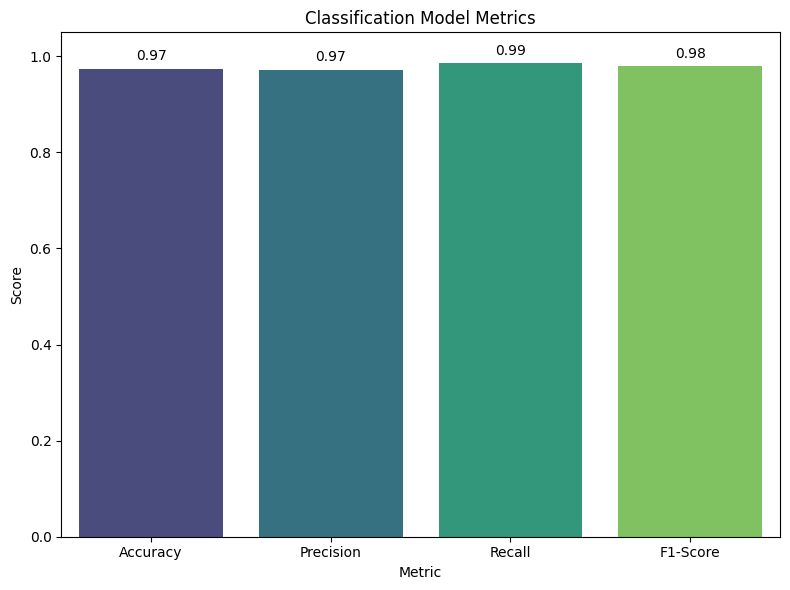

In [24]:

metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [accuracy, precision, recall, f1]
}
metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Metric', y='Value', hue='Metric', data=metrics_df, palette='viridis', legend=False)
plt.title('Classification Model Metrics')
plt.ylim(0, 1.05)
plt.ylabel('Score')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout() # Ensure tight layout
plt.show()

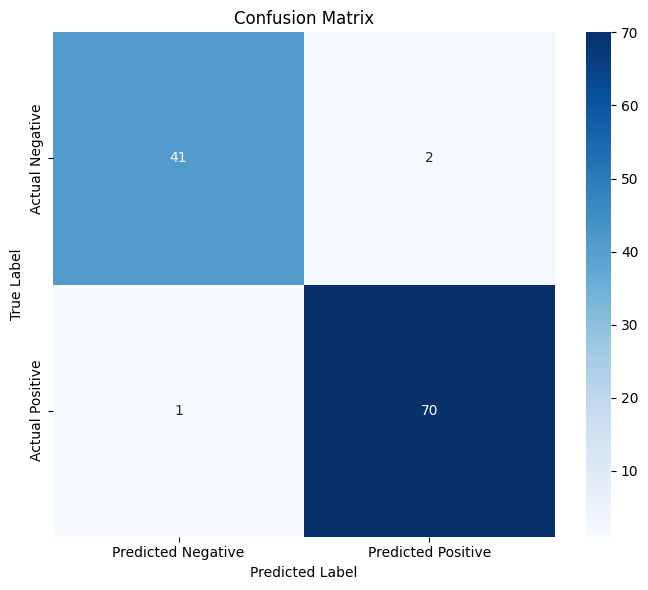

In [23]:

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

#### Evaluasi Model Klasifikasi

Model klasifikasi digunakan untuk memprediksi kategori atau kelas, seperti menentukan apakah email termasuk spam atau bukan, atau apakah seseorang memiliki penyakit atau tidak.

---

#### Confusion Matrix

Confusion Matrix adalah tabel yang digunakan untuk membandingkan hasil prediksi model dengan nilai aktual.

Struktur:

| | Pred Positif | Pred Negatif |
|--|--|--|
| Actual Positif | TP | FN |
| Actual Negatif | FP | TN |

Keterangan:

- TP = True Positive  
- TN = True Negative  
- FP = False Positive  
- FN = False Negative  

#### Accuracy

Accuracy mengukur persentase prediksi yang benar dibandingkan seluruh data.

Rumus Accuracy:

$$
Accuracy =
\frac{TP + TN}
{TP + TN + FP + FN}
$$

Cara membaca:

Jika Accuracy: 0.92


Artinya:

Model memprediksi dengan benar sebanyak **92%** dari seluruh data.

---

#### Precision

Precision mengukur seberapa banyak prediksi positif yang benar.

Rumus Precision:

$$
Precision =
\frac{TP}
{TP + FP}
$$

Cara membaca:

Jika Precision: 0.88


Artinya:

Dari semua prediksi positif, **88% benar**.

Precision penting jika False Positive harus kecil.

---

#### Recall

Recall mengukur seberapa banyak data positif yang berhasil ditemukan.

Rumus Recall:

$$
Recall =
\frac{TP}
{TP + FN}
$$

Cara membaca:

Jika Recall: 0.95


Artinya:

Model berhasil mendeteksi **95% data positif**.

Recall penting jika False Negative berbahaya.

---

#### F1-Score

F1-score merupakan gabungan precision dan recall.

Rumus F1-score:

$$
F1 =
\frac{2(Precision × Recall)}
{Precision + Recall}
$$

Cara membaca:

Jika F1-Score: 0.91

Artinya:

Model memiliki keseimbangan yang baik antara precision dan recall.

---


#### Model Evaluation Clustering

In [26]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Load dataset
data = load_iris()

X = data.data

# Model clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init='auto' # Suppress future warning for n_init
)

kmeans.fit(X)

labels = kmeans.labels_

# Evaluasi
silhouette = silhouette_score(X, labels)
davies_bouldin = davies_bouldin_score(X, labels)

print("Silhouette Score:", silhouette)
print("Davies-Bouldin Index:", davies_bouldin)

Silhouette Score: 0.551191604619592
Davies-Bouldin Index: 0.6660385791628493


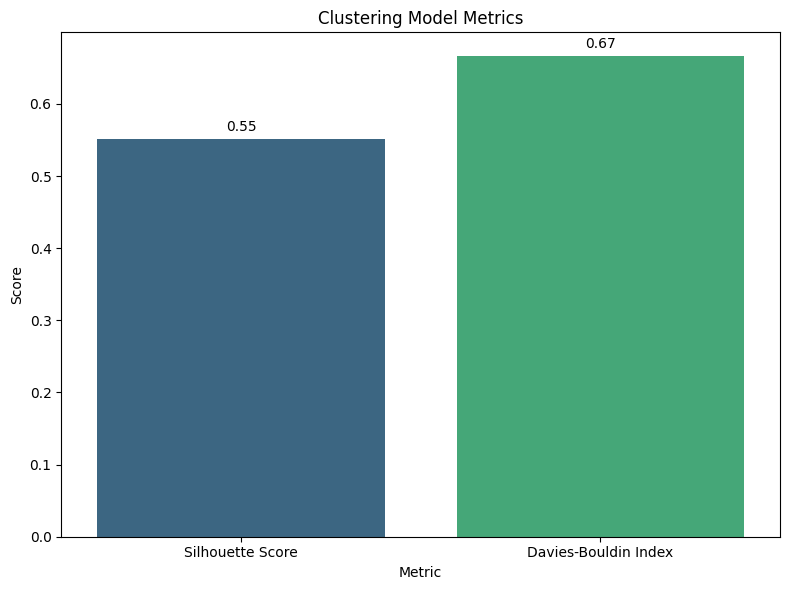

In [29]:
clustering_metrics_data = {
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index'],
    'Value': [silhouette, davies_bouldin]
}
clustering_metrics_df = pd.DataFrame(clustering_metrics_data)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Metric', y='Value', hue='Metric', data=clustering_metrics_df, palette='viridis', legend=False)
plt.title('Clustering Model Metrics')
plt.ylabel('Score')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.tight_layout()
plt.show()

#### Evaluasi Model Clustering

Model clustering digunakan untuk mengelompokkan data tanpa label.

---

#### Silhouette Score

Silhouette Score mengukur seberapa baik data berada dalam cluster-nya.

Rumus Silhouette:

$$
s =
\frac{b - a}
{\max(a, b)}
$$

di mana:

- $a$ = jarak rata-rata dalam cluster  
- $b$ = jarak rata-rata ke cluster lain  

Cara membaca:

Jika Silhouette score: 0.65


Artinya:

Cluster cukup baik dan terpisah dengan jelas.

Nilai:

- Mendekati 1 → sangat baik  
- Mendekati 0 → overlap  
- Negatif → buruk  

---

#### Davies-Bouldin Index (DBI)

DBI mengukur kualitas cluster berdasarkan jarak antar cluster.

Rumus DBI:

$$
DBI =
\frac{1}{k}
\sum_{i=1}^{k}
\max_{j \neq i}
\left(
\frac{S_i + S_j}
{M_{ij}}
\right)
$$

Cara membaca:

Jika DBI: 0.35

Artinya:

Cluster cukup baik.

Semakin kecil DBI → semakin baik.